In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from tqdm import tqdm
from typing import Union

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
data = pd.read_csv("../powerconsumption.csv")
data["Datetime"] = pd.to_datetime(data["Datetime"])
data = data.sort_values("Datetime").set_index("Datetime")

series = data["PowerConsumption_Zone1"].dropna()
print(f"Shape: {series.shape}")
print(f"Period: {series.index.min()} → {series.index.max()}")

Shape: (52416,)
Period: 2017-01-01 00:00:00 → 2017-12-30 23:50:00


In [3]:
TESTTIMESTEPS  = 1008        #1 week = 7 × 144
SEASONAL_M = 144         #daily cycle in 10 minutes data
TRAIN_WINDOW = 90 * 144    #90 days for the SARIMA fit (12,960)

train_full = series.iloc[:-TESTTIMESTEPS]
test = series.iloc[-TESTTIMESTEPS:]

train = train_full.iloc[-TRAIN_WINDOW:]

print(f"Train (full): {len(train_full):,} obs  ({len(train_full)/SEASONAL_M:.0f} days)")
print(f"Train (SARIMA): {len(train):,} obs  ({len(train)/SEASONAL_M:.0f} days)")
print(f"Test: {len(test):,} obs  ({len(test)/SEASONAL_M:.0f} days)")
print(f"\nSARIMA train range: {train.index.min()} → {train.index.max()}")
print(f"Test range: {test.index.min()} → {test.index.max()}")

Train (full): 51,408 obs  (357 days)
Train (SARIMA): 12,960 obs  (90 days)
Test: 1,008 obs  (7 days)

SARIMA train range: 2017-09-25 00:00:00 → 2017-12-23 23:50:00
Test range: 2017-12-24 00:00:00 → 2017-12-30 23:50:00


Seasonality

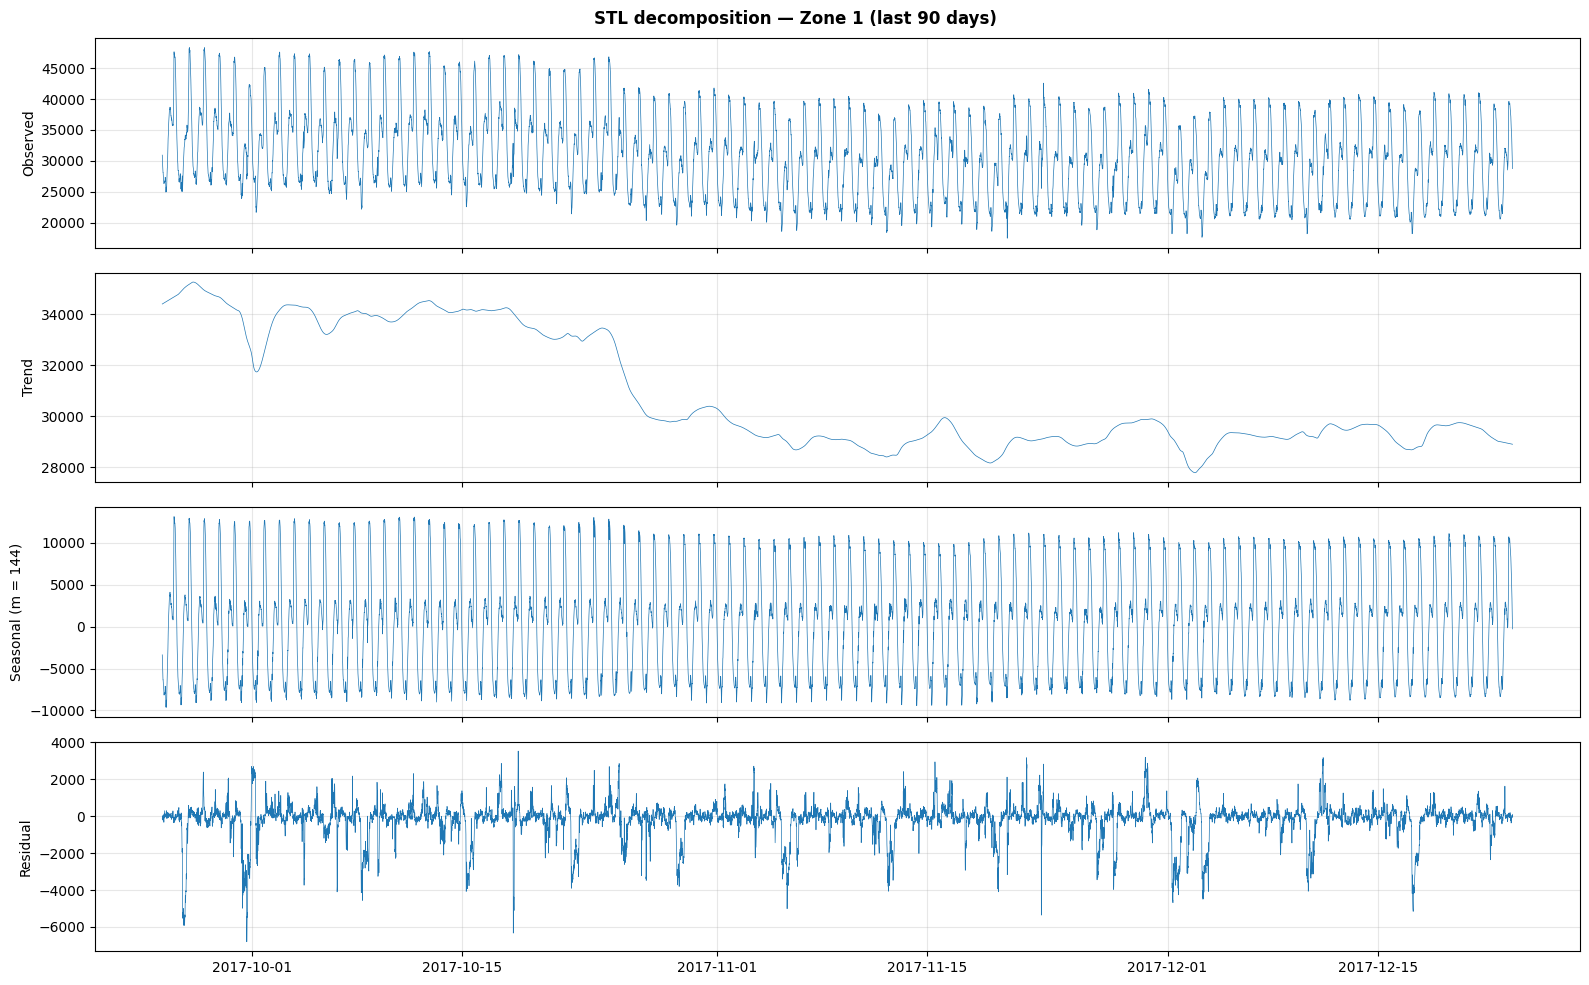

In [4]:
stl = STL(train, period=SEASONAL_M, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
for ax, (comp, title) in zip(axes, [
    (stl.observed, "Observed"),
    (stl.trend, "Trend"),
    (stl.seasonal, "Seasonal (m = 144)"),
    (stl.resid, "Residual"),
]):
    ax.plot(comp, linewidth=0.5)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
fig.suptitle("STL decomposition — Zone 1 (last 90 days)", fontweight="bold")
plt.tight_layout()
plt.show()

Stationarity

In [5]:
def adf_print(s, label):
    res = adfuller(s.dropna())
    print(f"{label:45s} ADF = {res[0]:8.3f} p-value = {res[1]:.4f}")

adf_print(train, "Raw")
adf_print(train.diff(), "After d = 1")
adf_print(train.diff().diff(SEASONAL_M), "After d = 1 and seasonal D = 1 (m = 144)")

Raw                                           ADF =  -17.305 p-value = 0.0000
After d = 1                                   ADF =  -18.064 p-value = 0.0000
After d = 1 and seasonal D = 1 (m = 144)      ADF =  -23.585 p-value = 0.0000


Grid Search

In [ ]:
def optimize_SARIMA(endog, p_r, q_r, P_r, Q_r, d, D, m) -> pd.DataFrame:
    rows = []
    combos = list(product(p_r, q_r, P_r, Q_r))
    for p, q, P, Q in tqdm(combos, leave=False):
        try:
            res = SARIMAX(endog,
                          order=(p, d, q),
                          seasonal_order=(P, D, Q, m),
                          simple_differencing=False,
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            rows.append([(p, d, q, P, D, Q, m), res.aic])
        except Exception:
            continue
    return (pd.DataFrame(rows, columns=["order", "AIC"])
              .sort_values("AIC")
              .reset_index(drop=True))


#the 30-day Mini-Train set (due to the computational cost of sarima it was imposible to tried with m = 144)
MINI_WINDOW = 7 * 144  #1008 observations
train_mini = train.iloc[-MINI_WINDOW:]

print("Grid Search for d=0")
grid_d0 = optimize_SARIMA(train_mini,
                          p_r=range(0, 2), q_r=range(0, 2),
                          P_r=range(0, 2), Q_r=range(0, 2),
                          d=0, D=1, m=144)

# 3. Run the search forcing d=1 and D=1
print("\nGrid Search for d=1")
grid_d1 = optimize_SARIMA(train_mini,
                          p_r=range(0, 2), q_r=range(0, 2),
                          P_r=range(0, 2), Q_r=range(0, 2),
                          d=1, D=1, m=144)

print("\n" + "="*35)
print("TOP 5 BEST MODELS WITH d=0")
print("="*35)
display(grid_d0.head(5))

print("\n" + "="*35)
print("TOP 5 BEST MODELS WITH d=1")
print("="*35)
display(grid_d1.head(5))

Grid Search for d=0


  0%|          | 0/16 [00:00<?, ?it/s]C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
  6%|▋         | 1/16 [00:06<01:43,  6.90s/it]C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min wi


Grid Search for d=1


  0%|          | 0/16 [00:00<?, ?it/s]C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
  6%|▋         | 1/16 [01:17<19:20, 77.40s/it]C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min wi

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print(">>> 1. Preparing the data (exactly 7 days)...")
MINI_WINDOW = 7 * 144  
train_mini = train.iloc[-MINI_WINDOW:]

print(">>> 2. Training the final SARIMA(1, 0, 1)x(0, 1, 1, 144) model...")
modelo_sarima = SARIMAX(train_mini, 
                        order=(1, 0, 1), 
                        seasonal_order=(0, 1, 1, 144),
                        enforce_stationarity=False, 
                        enforce_invertibility=False)

# Fit the model
resultados_sarima = modelo_sarima.fit(disp=False)

print("✅ Model trained successfully!")
print(resultados_sarima.summary())

>>> 1. Preparing the data (exactly 7 days)...
>>> 2. Training the final SARIMA(1, 0, 1)x(0, 1, 1, 144) model...


C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\alvarodela.herran\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


✅ Model trained successfully!
                                      SARIMAX Results                                      
Dep. Variable:              PowerConsumption_Zone1   No. Observations:                 1008
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 144)   Log Likelihood               -4858.057
Date:                             Sun, 17 May 2026   AIC                           9724.114
Time:                                     19:36:05   BIC                           9742.420
Sample:                                 12-17-2017   HQIC                          9731.182
                                      - 12-23-2017                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9798      0.007    132.965      0.000       0.965       0.9

Residual Diagnostics


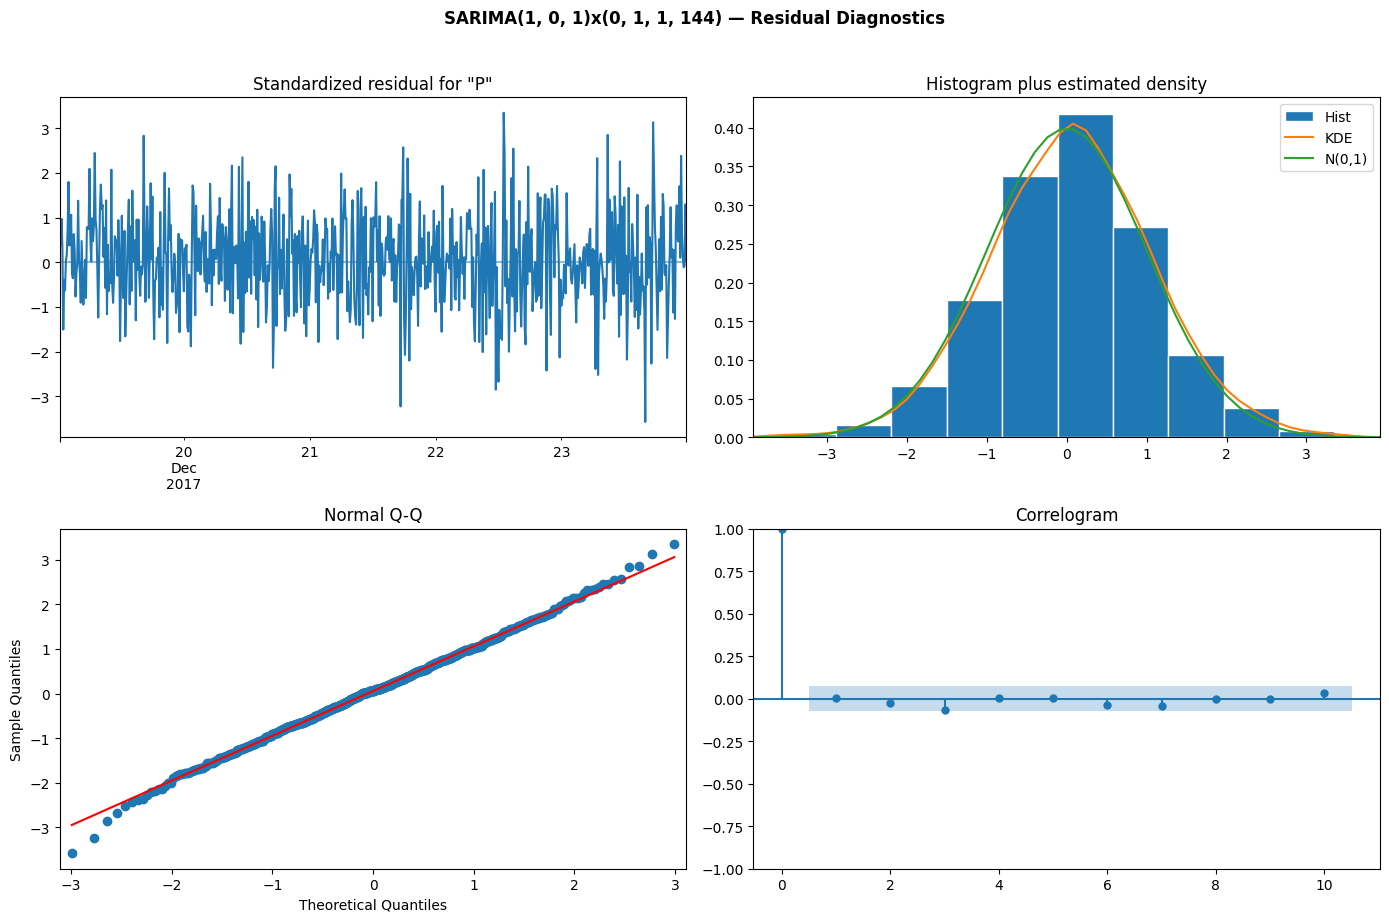

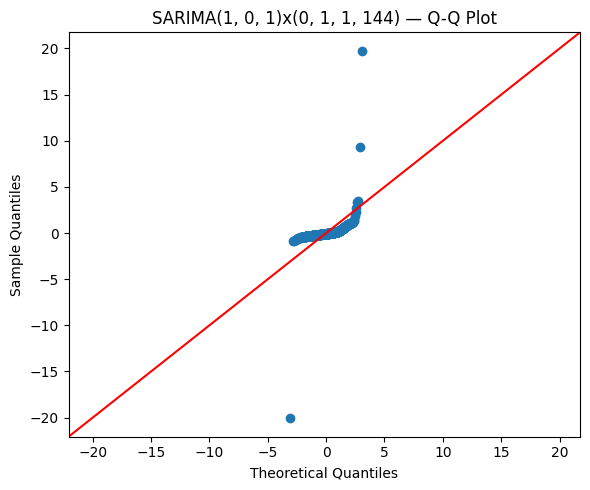

Ljung-Box test on the residuals:


,lb_stat,lb_pvalue
10,174.1331,0.0
20,202.7788,0.0
30,221.0503,0.0
50,250.2153,0.0
144,610.0998,0.0
288,615.7968,0.0


In [7]:
order_txt = "(1, 0, 1)"
seasonal_txt = "(0, 1, 1, 144)"

resultados_sarima.plot_diagnostics(figsize=(14, 9))
plt.suptitle(f"SARIMA{order_txt}x{seasonal_txt} — Residual Diagnostics",
             y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

fig = qqplot(resultados_sarima.resid, line="45", fit=True)
fig.set_size_inches(6, 5)
plt.title(f"SARIMA{order_txt}x{seasonal_txt} — Q-Q Plot")
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resultados_sarima.resid,
                    lags=[10, 20, 30, 50, 144, 288],
                    return_df=True)
print("Ljung-Box test on the residuals:")
display(lb.round(4))

Forecast 1 week

In [8]:
TESTTIMESTEPS = len(test)

forecast_result = resultados_sarima.get_forecast(steps=TESTTIMESTEPS)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int(alpha=0.05)

forecast_mean.index = test.index
forecast_ci.index   = test.index

print("Predictions generated successfully.")

Predictions generated successfully.


Baseline and MAPE

In [9]:
baseline_last = np.full(TESTTIMESTEPS, train.iloc[-1])
baseline_mean = np.full(TESTTIMESTEPS, train.mean())
baseline_naive_se = train.iloc[-TESTTIMESTEPS:].values

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

order_txt = "(1, 0, 1)"
seasonal_txt = "(0, 1, 1, 144)"

results = {
    "Baseline — Last value": mape(test.values, baseline_last),
    "Baseline — Train mean": mape(test.values, baseline_mean),
    "Baseline — Naïve seasonal (week)": mape(test.values, baseline_naive_se),
    f"SARIMA {order_txt}x{seasonal_txt}": mape(test.values, forecast_mean.values),
}

results_df = (pd.DataFrame.from_dict(results, orient="index", columns=["MAPE (%)"])
                .sort_values("MAPE (%)"))
print("\n--- RANKING ---")
print(results_df.round(2))


--- RANKING ---
                                  MAPE (%)
Baseline — Naïve seasonal (week)      2.05
SARIMA (1, 0, 1)x(0, 1, 1, 144)       3.68
Baseline — Last value                19.38
Baseline — Train mean                20.76


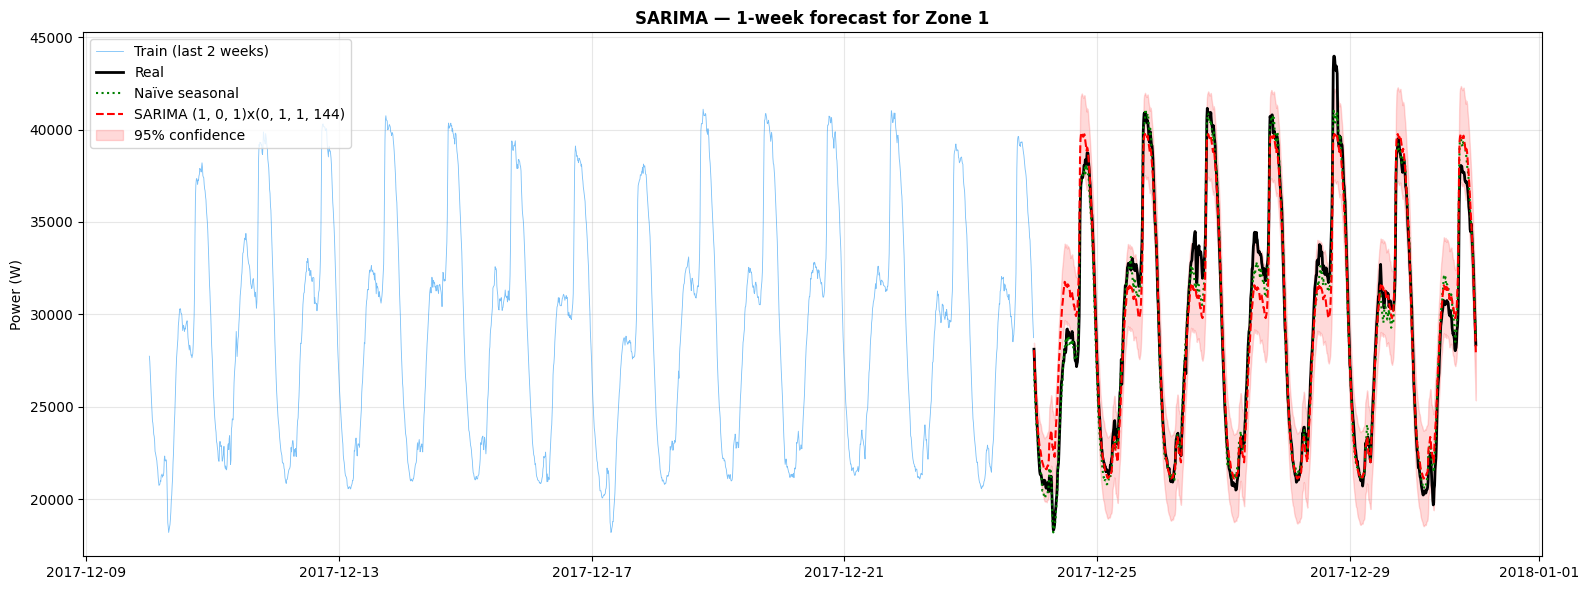

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

context = train.iloc[-2 * TESTTIMESTEPS:]
ax.plot(context.index, context.values, color="#2196F3", linewidth=0.6, alpha=0.6,
        label="Train (last 2 weeks)")

ax.plot(test.index, test.values, color="black", linewidth=2, label="Real")
ax.plot(test.index, baseline_naive_se, color="green", linestyle=":",
        label="Naïve seasonal")
ax.plot(test.index, forecast_mean.values, color="red", linewidth=1.5, linestyle="--",
        label=f"SARIMA {order_txt}x{seasonal_txt}")

ax.fill_between(test.index,
                forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color="red", alpha=0.15, label="95% confidence")

ax.set_title("SARIMA — 1-week forecast for Zone 1", fontweight="bold")
ax.set_ylabel("Power (W)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()